In [1]:
# DSE5002 Project 1 - Data Science Salary Analysis
# Analysis for CEO salary recommendation

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('project_1_data.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [2]:
# Basic info about the dataset
print(df.shape)
print(df.dtypes)
df.describe()

(607, 12)
Unnamed: 0            int64
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [9]:
# Map experience level codes to readable labels
exp_map = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
df['experience_label'] = df['experience_level'].map(exp_map)

# Flag US vs non-US employees
df['is_us'] = df['employee_residence'] == 'US'

# Filter to full time only for main analysis
ft_df = df[df['employment_type'] == 'FT']

            mean    median      std
Non-US   67754.0   62649.0  43155.0
US      149194.0  138475.0  68282.0


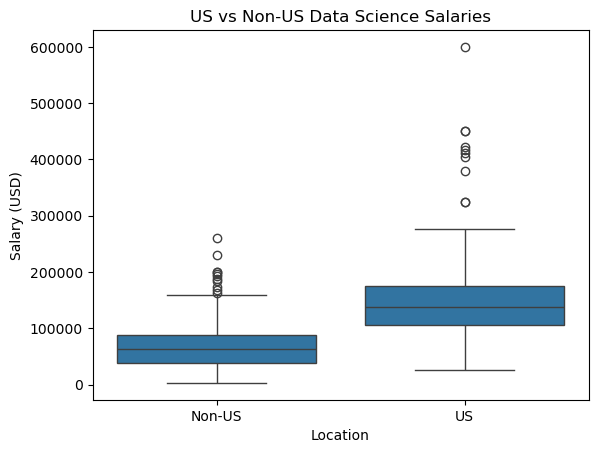

In [7]:
# Compare US vs non-US salaries
us_vs_other = df.groupby('is_us')['salary_in_usd'].agg(['mean', 'median', 'std']).round(0)
us_vs_other.index = ['Non-US', 'US']
print(us_vs_other)

sns.boxplot(data=df, x='is_us', y='salary_in_usd')
plt.xticks([0,1], ['Non-US', 'US'])
plt.title('US vs Non-US Data Science Salaries')
plt.xlabel('Location')
plt.ylabel('Salary (USD)')
plt.show()

experience_label
Executive    199392.038462
Senior       138617.292857
Mid           87996.056338
Entry         61643.318182
Name: salary_in_usd, dtype: float64


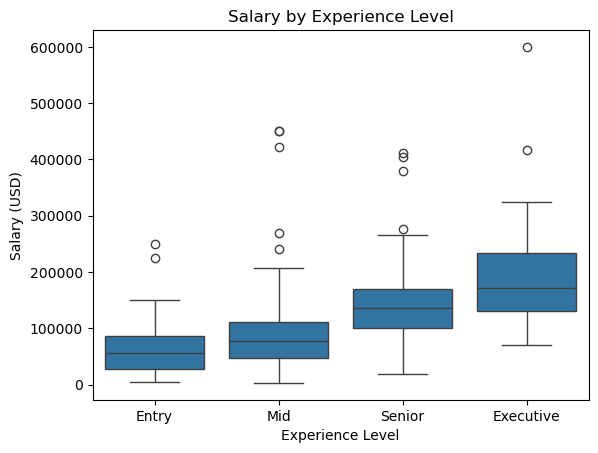

In [11]:
# Salary by experience level
exp_salary = df.groupby('experience_label')['salary_in_usd'].mean().sort_values(ascending=False)
print(exp_salary)

sns.boxplot(data=df, x='experience_label', y='salary_in_usd',
            order=['Entry', 'Mid', 'Senior', 'Executive'])
plt.title('Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

work_year
2020     95813.0
2021     99854.0
2022    124522.0
Name: salary_in_usd, dtype: float64


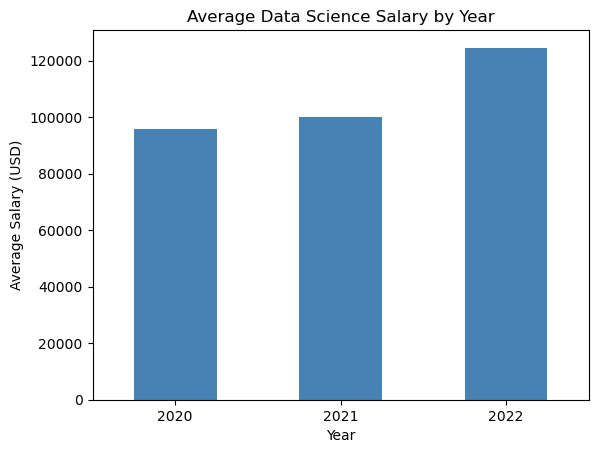

In [13]:
# Year over year salary growth
yearly = df.groupby('work_year')['salary_in_usd'].mean().round(0)
print(yearly)

yearly.plot(kind='bar', color='steelblue')
plt.title('Average Data Science Salary by Year')
plt.xlabel('Year')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=0)
plt.show()

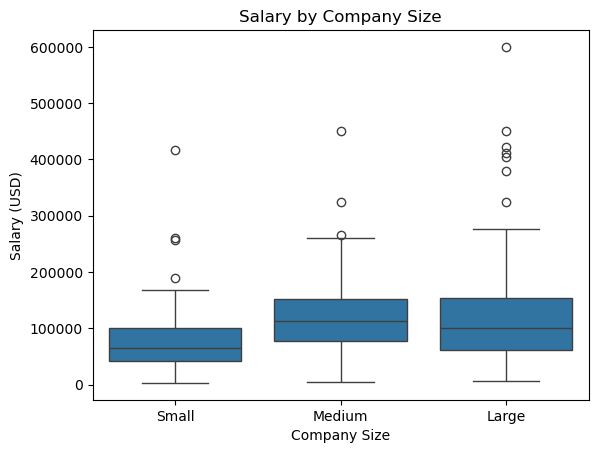

In [15]:
# Salary by company size
size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
df['company_size_label'] = df['company_size'].map(size_map)

sns.boxplot(data=df, x='company_size_label', y='salary_in_usd',
            order=['Small', 'Medium', 'Large'])
plt.title('Salary by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary (USD)')
plt.show()

job_title
Data Analytics Lead         405000.000000
Principal Data Engineer     328333.333333
Financial Data Analyst      275000.000000
Principal Data Scientist    215242.428571
Director of Data Science    195074.000000
Data Architect              177873.909091
Applied Data Scientist      175655.000000
Analytics Engineer          175000.000000
Data Specialist             165000.000000
Head of Data                160162.600000
Name: salary_in_usd, dtype: float64


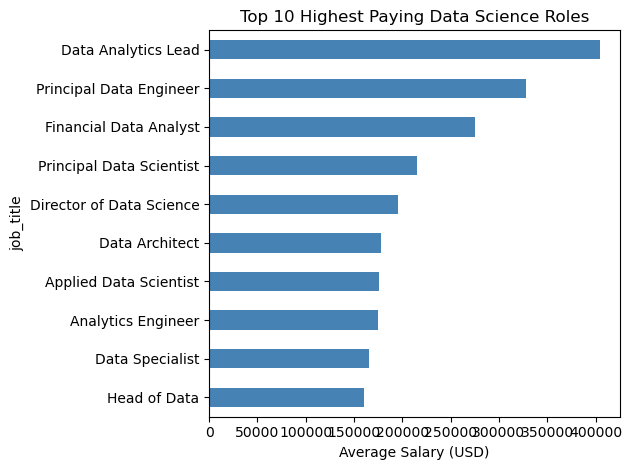

In [17]:
# Top 10 paying job titles
top_titles = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
print(top_titles)

top_titles.plot(kind='barh', color='steelblue')
plt.title('Top 10 Highest Paying Data Science Roles')
plt.xlabel('Average Salary (USD)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

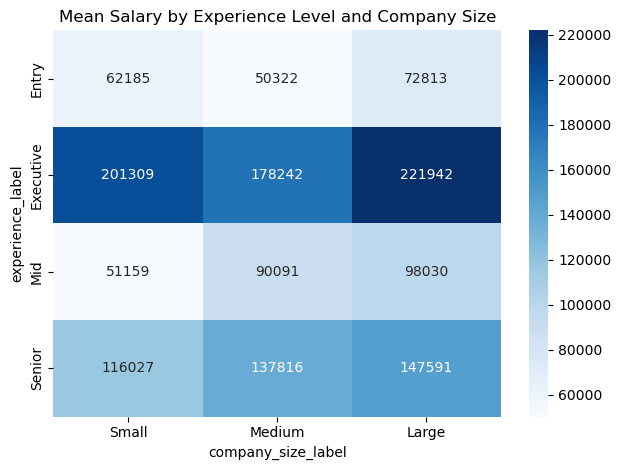

In [19]:
# Pivot table of experience level by company size
pivot = df.groupby(['experience_label', 'company_size_label'])['salary_in_usd'].mean().unstack()
pivot = pivot[['Small', 'Medium', 'Large']]

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Mean Salary by Experience Level and Company Size')
plt.tight_layout()
plt.show()

In [21]:
# Final recommendation numbers for CEO
us_df = df[df['employee_residence'] == 'US']
us_exp = us_df.groupby('experience_label')['salary_in_usd'].agg(['mean','median','min','max']).round(0)
print("US Salaries by Experience Level:")
print(us_exp)

US Salaries by Experience Level:
                      mean    median     min     max
experience_label                                    
Entry              98707.0   90000.0   50000  250000
Executive         249992.0  224000.0  110000  600000
Mid               135618.0  118000.0   37236  450000
Senior            153922.0  150000.0   25000  412000


In [ ]:
Based on this analysis, I recommend the following salary ranges for a 
US-based data scientist hire:

- Entry Level: $90,000 - $110,000
- Mid Level: $118,000 - $150,000  
- Senior Level: $150,000 - $175,000
- Executive/Director: $224,000 - $275,000

Given that salaries have grown 30% from 2020 to 2022 and the market is 
highly competitive, I recommend targeting the upper half of these ranges 
to attract top talent. A Senior-level hire at $150,000-$175,000 would be 
the best starting point for building a data science capability.